In [10]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import functools
import tqdm
import glob
import IPython.display as ipd

import modules
import utils
importlib.reload(modules)

import datasets
importlib.reload(datasets)

import soundfile as sf


In [25]:
importlib.reload(datasets)
dataset = datasets.WavFiles(preload=True, dbspl=(30, 90))

print(len(dataset))
for _ in tqdm.tqdm(range(10000)):
    dataset[np.random.randint(len(dataset))]

out = dataset[-1]
out

100



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 66912.41it/s]

{'sr': 20000,
 'signal': array([-0.00039673,  0.00021362, -0.00018311, ..., -0.04507446,
        -0.02688599, -0.01516724], shape=(40000,), dtype=float32),
 'dbspl': 49.35855982420796,
 'filename': 'data/099.wav'}

In [5]:
list_filename = glob.glob("data/*.wav")
print(f"Found {len(list_filename)} wav files in the data directory")

filename = list_filename[-1]
x, sr = sf.read(filename)  # Use `soundfile` package to load a wav file
print(f"Loaded `{filename}`: {x.shape=}, {x.dtype=}, {sr=} Hz")

ipd.display(ipd.Audio(rate=sr, data=x))


Found 100 wav files in the data directory
Loaded `data/091.wav`: x.shape=(40000,), x.dtype=dtype('float64'), sr=20000 Hz


In [143]:
dataset = datasets.SyntheticVowels(
    sr=20000,
    dur=0.25,
    f0_list=[120],
    dbspl_list=[60],
)
# dataset = datasets.SyntheticInstruments()
print(len(dataset))
for _ in tqdm.tqdm(range(1000)):
    dataset[0]
dataset[0]


10



00%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6590.78it/s]

{'sr': 20000,
 'signal': array([-0.0029473 , -0.0029473 , -0.00294726, ..., -0.00294734,
        -0.00294732, -0.0029473 ], shape=(5000,), dtype=float32),
 'dbspl': np.float64(60.0),
 'f0': np.float64(120.0),
 'vowel': 0,
 'vowel_str': '/i/ (heed)'}


/Users/marksa/Desktop/auditory_machine_learning/utils.py:97: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))
  9.78it/s]

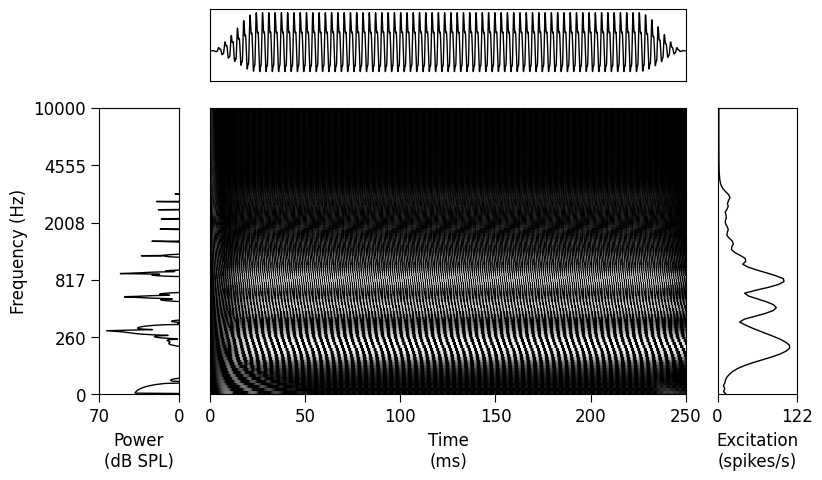

In [262]:
cochlear_model = modules.CochlearModel(
    sr_input=20000,
    sr_output=10000,
    fir_dur=0.050,
    cfs=utils.erbspace(8e1, 8e3, 100),
    bw_mult=1.0,
    ihc_lowpass_cutoff=3000,
    ihc_lowpass_order=7,
    threshold=0.0,
    dynamic_range=80.0,
)
for _ in tqdm.tqdm(range(10)):
    out = dataset[0]
    signal = out["signal"]
    nervegram = cochlear_model(signal)

waveform = signal
nervegram = nervegram.numpy()

fig, ax = utils.make_nervegram_plot(
    waveform=waveform,
    nervegram=nervegram,
    sr_waveform=cochlear_model.sr_input,
    sr_nervegram=cochlear_model.sr_output,
)
plt.show()


In [254]:
class CochlearNet(nn.Module):
    def __init__(self, n_classes=10):
        """ """
        super().__init__()
        self.cochlear_model = modules.CochlearModel(
            sr_input=20000,
            sr_output=500,
            fir_dur=0.05,
            cfs=utils.erbspace(8e1, 8e3, 50),
            bw_mult=1.0,
            ihc_lowpass_cutoff=50,
            ihc_lowpass_order=7,
            threshold=0.0,
            dynamic_range=80.0,
        )
        self.network_model = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((25, 25)),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(start_dim=1, end_dim=-1),
        )
        self.readout = nn.Linear(16, n_classes)

    def forward(self, x):
        """ """
        x = self.cochlear_model(x)  # [batch, time] --> [batch, freq, time]
        x = x.unsqueeze(1)  # [batch, freq, time] --> [batch, 1, freq, time]
        x = self.network_model(x)  # [batch, 1, freq, time] --> [batch, features]
        x = self.readout(x)  # [batch, features] --> [batch, n_classes]
        return x

tmp = CochlearNet()
tmp

# x = example["signal"].to(device)
# tmp(x)


CochlearNet(
  (cochlear_model): CochlearModel(
    (cochlear_filterbank): GammatoneFilterbank()
    (half_wave_rectification): ReLU()
    (ihc_lowpass_filter): IHCLowpassFilter()
    (rate_level_function): SigmoidRateLevelFunction()
  )
  (network_model): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AdaptiveAvgPool2d(output_size=(25, 25))
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AdaptiveAvgPool2d(output_size=(1, 1))
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (readout): Linear(in_features=16, out_features=10, bias=True)
)

In [292]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class TinyVowelNet(nn.Module):
    def __init__(self, n_classes=10):
        """ """
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=9, stride=2, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(500),
            nn.Conv1d(8, 16, kernel_size=9, stride=2, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(start_dim=1, end_dim=-1),
        )
        # self.readout = nn.Linear(16, n_classes)
        self.readout = nn.LazyLinear(n_classes)

    def forward(self, x):
        """ """
        x = x.unsqueeze(1)  # [batch, 1, time]
        x = self.network(x)  # [batch, features]
        x = self.readout(x)  # [batch, n_classes]
        return x


model = TinyVowelNet().to(device)
# model = CochlearNet().to(device)
model = model.train(True)
trainable_parameters = list(model.parameters())
optimizer = torch.optim.Adam(trainable_parameters, lr=1e-3)
loss_function = nn.CrossEntropyLoss()

dataset_train = datasets.SyntheticVowels(n_examples=10000, random_seed=0)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)

for epoch in range(10):
    epoch_loss = 0
    epoch_n_total = 0
    epoch_n_correct = 0
    for step, example in tqdm.tqdm(enumerate(dataloader_train)):
        x = example["signal"].to(device)
        y = example["vowel"].to(device)
        logits = model(x)
        loss = loss_function(logits, y)
        preds = torch.argmax(logits, dim=1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_n_total += y.shape[0]
        epoch_n_correct += (preds == y).sum().item()
    epoch_loss = epoch_loss / len(dataloader_train)
    epoch_acc = epoch_n_correct / epoch_n_total
    print(f"epoch {epoch}: loss = {epoch_loss:.3f}, accuracy = {epoch_acc:.3f}")



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1250/1250 [00:02<00:00, 528.26it/s]

epoch 0: loss = 2.184, accuracy = 0.221



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1250/1250 [00:02<00:00, 535.60it/s]

epoch 1: loss = 1.618, accuracy = 0.549



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1250/1250 [00:02<00:00, 534.40it/s]

...

epoch 7: loss = 0.826, accuracy = 0.788



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1250/1250 [00:02<00:00, 508.38it/s]

epoch 8: loss = 0.760, accuracy = 0.802


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1250/1250 [00:02<00:00, 504.75it/s]

epoch 9: loss = 0.696, accuracy = 0.820


In [293]:
dataset_eval = datasets.SyntheticVowels(
    dbspl_list=[60],
    f0_list=utils.logspace(100, 400, 100),
    random_seed=1,
)
print(len(dataset_eval))
dataloader_eval = torch.utils.data.DataLoader(dataset_eval, batch_size=8)

model = model.train(False)

list_y_true = []
list_y_pred = []
for example in tqdm.tqdm(dataloader_eval):
    x = example["signal"].to(device)
    y = example["vowel"].to(device)
    logits = model(x)
    preds = torch.argmax(logits, dim=1)
    list_y_true.append(y.detach().cpu())
    list_y_pred.append(preds.detach().cpu())
    
list_y_true = np.concatenate(list_y_true)
list_y_pred = np.concatenate(list_y_pred)
accuracy = np.mean(list_y_pred == list_y_true)
accuracy


1000



00%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:00<00:00, 604.08it/s]

np.float64(0.876)

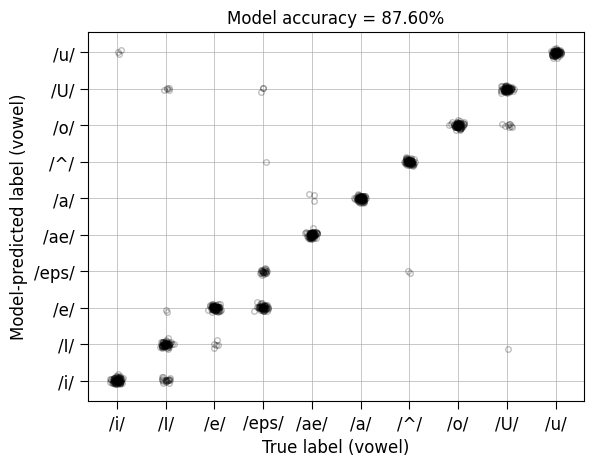

In [295]:
fig, ax = plt.subplots()
ax.plot(
    list_y_true + 0.05 * np.random.randn(len(list_y_true)),
    list_y_pred + 0.05 * np.random.randn(len(list_y_pred)),
    marker="o",
    color="k",
    mfc="none",
    mew=1,
    ms=4,
    ls="",
    alpha=0.25,
)
ticks = []
ticklabels = []
for k, v in dataset_train.map_vowel_to_str.items():
    ticks.append(k)
    ticklabels.append(v.split(" ")[0])
ax = utils.format_axes(
    ax,
    str_title=f"Model accuracy = {100 * accuracy:.2f}%",
    str_xlabel="True label (vowel)",
    str_ylabel="Model-predicted label (vowel)",
    xticks=ticks,
    xticklabels=ticklabels,
    yticks=ticks,
    yticklabels=ticklabels,
)
ax.grid(lw=0.5)
plt.show()


/Users/marksa/Desktop/auditory_ml_tutorial/modules.py:429: RuntimeWarning: divide by zero encountered in log
  elif self.scale.lower() == "linear":


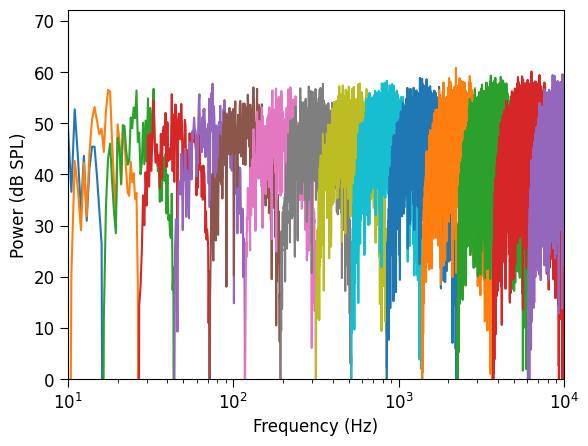

In [90]:
# impulse = torch.zeros(10000)
# impulse[0] = 1

impulse = torch.randn(40000)

filterbank = modules.HalfCosineFilterbank(
    sr=20000,
    cf_low=10e0,
    cf_high=10e3,
    cf_num=15,
    scale="log",
    include_highpass=False,
    include_lowpass=False,
)

fir = filterbank(impulse)

fig, ax = utils.make_periodogram_plot(fir, sr=20000)
ax.set_ylim([0, None])
plt.show()


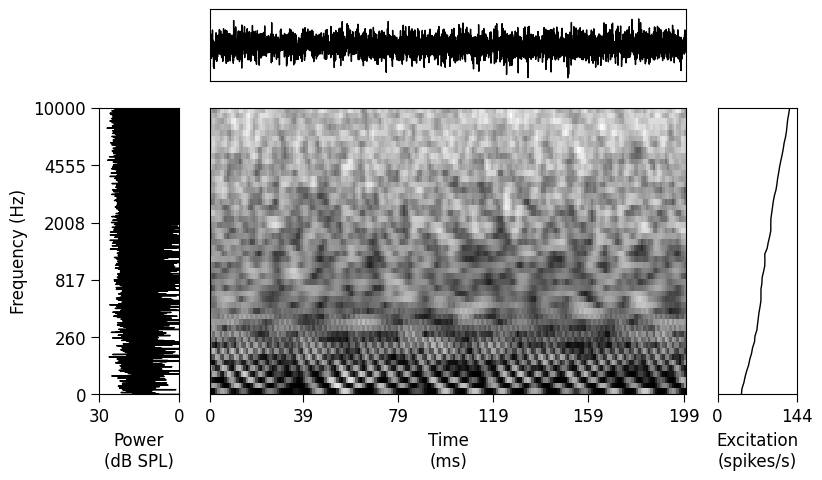

In [123]:
importlib.reload(modules)

sr = 20000
sr_output = 1000
model = modules.CochlearModel(
    sr_input=sr,
    sr_output=sr_output,
    fir_dur=0.05,
    cfs=utils.erbspace(8e1, 8e3, 50),
    bw_mult=1.0,
    ihc_lowpass_cutoff=300,
    ihc_lowpass_order=7,
    threshold=0.0,
    dynamic_range=80.0,
    dtype=torch.float32,
)
waveform = utils.set_dbspl(np.random.randn(2 * sr), 60)
nervegram = model(waveform).numpy()

fig, ax = utils.make_nervegram_plot(
    waveform=waveform,
    nervegram=nervegram,
    sr_waveform=sr,
    sr_nervegram=sr_output,
    tmin=0.050,
    tmax=0.250,
)


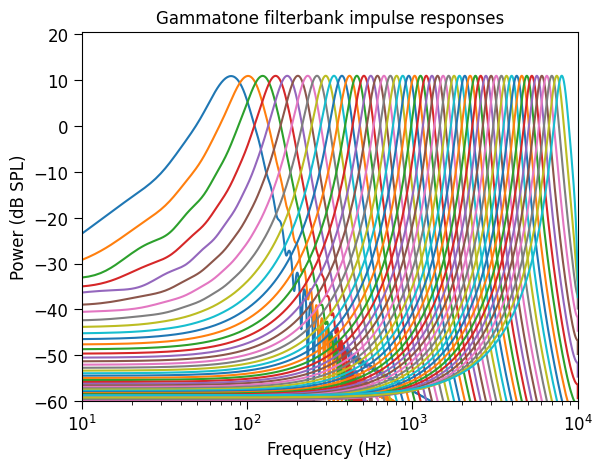

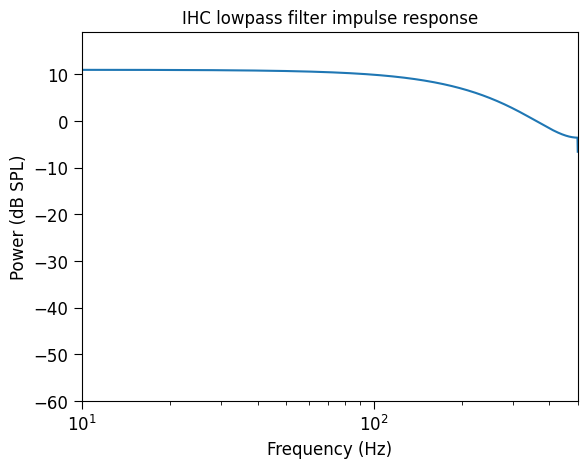

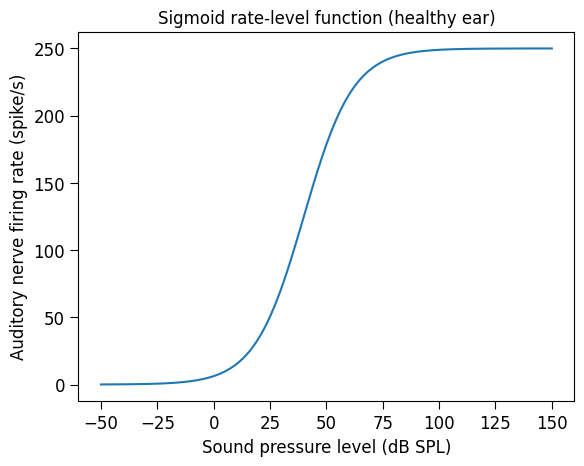

In [115]:
impulse = torch.zeros(model.sr_input)
impulse[0] = 1


impulse_response = model.cochlear_filterbank(impulse)
fig, ax = utils.make_periodogram_plot(
    impulse_response,
    sr=sr,
    str_title="Gammatone filterbank impulse responses",
    # ylimits=[-30, None],
)
plt.show()


impulse_response = model.ihc_lowpass_filter(impulse)
fig, ax = utils.make_periodogram_plot(
    impulse_response,
    sr=sr_output,
    str_title="IHC lowpass filter impulse response",
    # ylimits=[-30, None],
)
plt.show()


fig, ax = plt.subplots()
x_db = np.arange(-50, 151)
x_pa = 20e-6 * (10 ** (x_db / 20))
y = model.rate_level_function(torch.as_tensor(x_pa))
ax.plot(x_db, y)
ax = utils.format_axes(
    ax,
    str_xlabel="Sound pressure level (dB SPL)",
    str_ylabel="Auditory nerve firing rate (spike/s)",
    str_title="Sigmoid rate-level function (healthy ear)",
)
plt.show()


In [105]:
x = torch.ones([1, 5])
x = x.unsqueeze(-2)
unflatten_shape = x.shape[:-2]

x = torch.flatten(x, start_dim=0, end_dim=-2 - 1)
unflatten_shape, x.shape


(torch.Size([1]), torch.Size([1, 1, 5]))

In [37]:
importlib.reload(modules)
model = modules.CochlearModel()
model.rate_level_function(torch.zeros(5, 1, 1000)).shape


torch.Size([5, 1, 1000])

In [13]:
impulse = torch.zeros(1000)
impulse[0] = 1

model.cochlear_filterbank(impulse).shape


torch.Size([100, 1000])